<a href="https://colab.research.google.com/github/Yennybel01/ALGORITMOS-GENETICOS-EN-MACHINE-LEARNING/blob/main/Actividad_02.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Feature Selection**

In [ ]:
"""
==============================================================================
ALGORITMO GENÉTICO PARA SELECCIÓN DE CARACTERÍSTICAS (Feature Selection)
Dataset: Mushroom Classification (UCI / Kaggle)
==============================================================================
"""

import numpy as np
import pandas as pd
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import cross_val_score, StratifiedKFold
from sklearn.preprocessing import LabelEncoder
import random

# ─────────────────────────────────────────────────────────────────────────────
# 0. CARGA DEL DATASET REAL
# ─────────────────────────────────────────────────────────────────────────────
df = pd.read_csv('mushrooms.csv')
le = LabelEncoder()
for col in df.columns:
    df[col] = le.fit_transform(df[col])

X = df.drop('class', axis=1).values
y = df['class'].values

FEATURE_NAMES = list(df.drop('class', axis=1).columns)
n_features    = X.shape[1]
cv            = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# ─────────────────────────────────────────────────────────────────────────────
# 1. REPRESENTACIÓN DE LA POBLACIÓN (cromosomas binarios)
# ─────────────────────────────────────────────────────────────────────────────
# Cada cromosoma = vector binario de longitud n_features (22 genes)
# Gen = 1 → característica SELECCIONADA
# Gen = 0 → característica DESCARTADA
#
# Ejemplo visual:
#   Posición: [ 0         1           2          3        4     ... 21      ]
#   Feature:  [ cap-shape cap-surface cap-color  bruises  odor  ... habitat ]
#   Cromosoma:[ 1         0           1          1        0     ... 1       ]
#               ↑ usa                 ↑ usa      ↑ usa          ↑ usa

np.random.seed(0)
ejemplo_cromosoma = np.random.randint(0, 2, n_features)
print("=" * 60)
print(" REPRESENTACIÓN DEL CROMOSOMA")
print("=" * 60)
print(f"  Genes (22 bits): {ejemplo_cromosoma.tolist()}")
print(f"  Features activas ({ejemplo_cromosoma.sum()}): "
      f"{[FEATURE_NAMES[i] for i, g in enumerate(ejemplo_cromosoma) if g == 1]}")
print(f"  Features descartadas ({n_features - ejemplo_cromosoma.sum()}): "
      f"{[FEATURE_NAMES[i] for i, g in enumerate(ejemplo_cromosoma) if g == 0]}")
print()

# ─────────────────────────────────────────────────────────────────────────────
# 2. INICIALIZACIÓN
# ─────────────────────────────────────────────────────────────────────────────
def initialize_population(pop_size, n_genes, min_features=2):
    """
    Genera pop_size cromosomas binarios aleatorios.
    Garantiza al menos min_features genes activos por cromosoma.
    """
    population = []
    for _ in range(pop_size):
        while True:
            chrom = np.random.randint(0, 2, n_genes)
            if chrom.sum() >= min_features:
                break
        population.append(chrom)
    return population

# ─────────────────────────────────────────────────────────────────────────────
# 3. FUNCIÓN DE APTITUD (fitness)
# ─────────────────────────────────────────────────────────────────────────────
def fitness(chromosome, X, y, cv, alpha=0.01):
    """
    fitness = accuracy_CV - alpha * (proporción de features usadas)
    Penaliza usar demasiadas características → prefiere soluciones compactas.
    """
    selected = np.where(chromosome == 1)[0]
    if len(selected) == 0:
        return 0.0
    X_sel  = X[:, selected]
    model  = RandomForestClassifier(n_estimators=30, random_state=42)
    scores = cross_val_score(model, X_sel, y, cv=cv, scoring="accuracy")
    acc     = scores.mean()
    penalty = alpha * (len(selected) / len(chromosome))
    return acc - penalty

# ─────────────────────────────────────────────────────────────────────────────
# 4. SELECCIÓN (torneo binario)
# ─────────────────────────────────────────────────────────────────────────────
def tournament_selection(population, fitnesses, k=3):
    """
    Selecciona un individuo eligiendo k candidatos al azar
    y devolviendo el de mayor fitness (torneo).
    """
    idx  = random.sample(range(len(population)), k)
    best = max(idx, key=lambda i: fitnesses[i])
    return population[best].copy()

# ─────────────────────────────────────────────────────────────────────────────
# 5. CRUZAMIENTO (un punto)
# ─────────────────────────────────────────────────────────────────────────────
def single_point_crossover(parent1, parent2, prob=0.8):
    """
    Cruzamiento de un punto: elige un punto aleatorio y
    combina los segmentos de ambos padres para crear dos hijos.
    """
    if random.random() < prob:
        point  = random.randint(1, len(parent1) - 1)
        child1 = np.concatenate([parent1[:point], parent2[point:]])
        child2 = np.concatenate([parent2[:point], parent1[point:]])
        return child1, child2
    return parent1.copy(), parent2.copy()

# ─────────────────────────────────────────────────────────────────────────────
# 6. MUTACIÓN (bit-flip)
# ─────────────────────────────────────────────────────────────────────────────
def bit_flip_mutation(chromosome, prob=0.05):
    """
    Invierte cada bit del cromosoma con probabilidad prob.
    Garantiza al menos 1 feature activa tras la mutación.
    """
    mutant = chromosome.copy()
    for i in range(len(mutant)):
        if random.random() < prob:
            mutant[i] = 1 - mutant[i]   # 0 → 1  ó  1 → 0
    if mutant.sum() == 0:
        mutant[random.randint(0, len(mutant) - 1)] = 1
    return mutant

# ─────────────────────────────────────────────────────────────────────────────
# 7. CICLO PRINCIPAL DEL ALGORITMO GENÉTICO
# ─────────────────────────────────────────────────────────────────────────────
def genetic_algorithm_feature_selection(
    X, y, pop_size=20, n_generations=15,
    crossover_prob=0.8, mutation_prob=0.05, elitism=2, verbose=True
):
    n_genes    = X.shape[1]
    population = initialize_population(pop_size, n_genes)

    best_fitness_history = []
    avg_fitness_history  = []
    best_chromosome      = None
    best_fit             = -np.inf

    print(f"{'Gen':>4} | {'Mejor Fit':>10} | {'Prom Fit':>10} | {'# Features':>10}")
    print("-" * 48)

    for gen in range(n_generations):

        # --- Evaluar aptitud de toda la población ---
        fitnesses    = [fitness(c, X, y, cv) for c in population]
        gen_best_fit = max(fitnesses)
        gen_avg_fit  = np.mean(fitnesses)
        best_fitness_history.append(gen_best_fit)
        avg_fitness_history.append(gen_avg_fit)

        # --- Guardar el mejor individuo global ---
        best_idx = np.argmax(fitnesses)
        if fitnesses[best_idx] > best_fit:
            best_fit        = fitnesses[best_idx]
            best_chromosome = population[best_idx].copy()

        n_sel = int(best_chromosome.sum())
        if verbose:
            print(f"{gen+1:>4} | {gen_best_fit:>10.4f} | {gen_avg_fit:>10.4f} | {n_sel:>10}")

        # --- Elitismo: conservar los k mejores ---
        elite_idx = np.argsort(fitnesses)[-elitism:]
        new_pop   = [population[i].copy() for i in elite_idx]

        # --- Generar nueva población ---
        while len(new_pop) < pop_size:
            p1      = tournament_selection(population, fitnesses)   # selección
            p2      = tournament_selection(population, fitnesses)   # selección
            c1, c2  = single_point_crossover(p1, p2, crossover_prob)  # cruzamiento
            c1      = bit_flip_mutation(c1, mutation_prob)          # mutación
            c2      = bit_flip_mutation(c2, mutation_prob)          # mutación
            new_pop.extend([c1, c2])

        population = new_pop[:pop_size]

    # ── TERMINACIÓN ──────────────────────────────────────────────────────────
    selected_features = np.where(best_chromosome == 1)[0]
    print(f"\n✔  Mejor cromosoma encontrado:")
    print(f"   Cromosoma (bits): {best_chromosome.tolist()}")
    print(f"   Características seleccionadas ({len(selected_features)}/{n_genes}): "
          f"{[FEATURE_NAMES[i] for i in selected_features]}")
    print(f"   Fitness final: {best_fit:.4f}")

    return best_chromosome, best_fitness_history, avg_fitness_history

# ─────────────────────────────────────────────────────────────────────────────
# EJECUCIÓN
# ─────────────────────────────────────────────────────────────────────────────
if __name__ == "__main__":
    print("=" * 60)
    print(" AG - SELECCIÓN DE CARACTERÍSTICAS | Mushroom Dataset")
    print("=" * 60)

    best_chrom, best_hist, avg_hist = genetic_algorithm_feature_selection(
        X, y, pop_size=20, n_generations=15,
        crossover_prob=0.8, mutation_prob=0.05, elitism=2, verbose=True
    )

    # --- Comparación final: todas las features vs las seleccionadas por el AG ---
    selected   = np.where(best_chrom == 1)[0]
    model_full = RandomForestClassifier(n_estimators=100, random_state=42)
    model_sel  = RandomForestClassifier(n_estimators=100, random_state=42)

    acc_full = cross_val_score(model_full, X,              y, cv=cv).mean()
    acc_sel  = cross_val_score(model_sel,  X[:, selected], y, cv=cv).mean()

    print(f"\n📊 Comparación final:")
    print(f"   Accuracy (todas las {n_features} features): {acc_full:.4f}")
    print(f"   Accuracy ({len(selected)} features AG):     {acc_sel:.4f}")
    print(f"   Reducción de dimensionalidad: "
          f"{(1 - len(selected)/n_features)*100:.1f}%")

 REPRESENTACIÓN DEL CROMOSOMA
  Genes (22 bits): [0, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 1]
  Features activas (12): ['cap-surface', 'cap-color', 'odor', 'gill-attachment', 'gill-spacing', 'gill-size', 'gill-color', 'stalk-shape', 'stalk-root', 'stalk-color-above-ring', 'spore-print-color', 'habitat']
  Features descartadas (10): ['cap-shape', 'bruises', 'stalk-surface-above-ring', 'stalk-surface-below-ring', 'stalk-color-below-ring', 'veil-type', 'veil-color', 'ring-number', 'ring-type', 'population']

 AG - SELECCIÓN DE CARACTERÍSTICAS | Mushroom Dataset
 Gen |  Mejor Fit |   Prom Fit | # Features
------------------------------------------------
   1 |     0.9968 |     0.9918 |          7
   2 |     0.9968 |     0.9946 |          7
   3 |     0.9968 |     0.9958 |          7
   4 |     0.9968 |     0.9937 |          7
   5 |     0.9973 |     0.9958 |          6
   6 |     0.9973 |     0.9964 |          6
   7 |     0.9973 |     0.9904 |          6
   8 |     0

HYPERPARAMETER

In [ ]:
# ============================================================
# ALGORITMO GENÉTICO PARA OPTIMIZACIÓN DE HIPERPARÁMETROS
# Dataset: Mushroom Classification (UCI / Kaggle)
# ============================================================

# ── Celda 1: Instalar dependencias ──────────────────────────
!pip install kaggle -q

# ── Celda 2: Subir kaggle.json (corre esta celda) ───────────
from google.colab import files
files.upload()  # sube tu kaggle.json

!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

# ── Celda 3: Descargar dataset ──────────────────────────────
!kaggle datasets download -d uciml/mushroom-classification --unzip

# ── Celda 4: Imports ────────────────────────────────────────
import numpy as np
import pandas as pd
import random
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import cross_val_score, StratifiedKFold
from sklearn.preprocessing import LabelEncoder

# ── Celda 5: Carga y preprocesamiento ───────────────────────
df = pd.read_csv('mushrooms.csv')
le = LabelEncoder()
for col in df.columns:
    df[col] = le.fit_transform(df[col])

X = df.drop('class', axis=1).values
y = df['class'].values

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

print(f"Dataset cargado: {X.shape[0]} muestras, {X.shape[1]} características")
print(f"Clases: {np.unique(y)}  (0=comestible, 1=venenoso)")

Saving mushrooms (1).csv to mushrooms (1).csv
cp: cannot stat 'kaggle.json': No such file or directory
chmod: cannot access '/root/.kaggle/kaggle.json': No such file or directory
Dataset URL: https://www.kaggle.com/datasets/uciml/mushroom-classification
License(s): CC0-1.0
100% 34.2k/34.2k [00:00<00:00, 65.1MB/s]

Dataset cargado: 8124 muestras, 22 características
Clases: [0 1]  (0=comestible, 1=venenoso)


In [ ]:
# ── Celda 6: DEFINICIÓN DEL ESPACIO DE HIPERPARÁMETROS ──────
# =============================================================
# REPRESENTACIÓN (paso 1 del ciclo AG)
# Cromosoma = lista de 4 genes, cada gen es un hiperparámetro:
#   Gen 0 → n_estimators  (número de árboles)
#   Gen 1 → max_depth      (profundidad máxima del árbol)
#   Gen 2 → min_samples_split
#   Gen 3 → max_features   (fracción de features por split)
# =============================================================

PARAM_GRID = {
    'n_estimators':       [10, 20, 30, 50, 75, 100, 150, 200],
    'max_depth':          [2, 4, 6, 8, 10, None],
    'min_samples_split':  [2, 4, 6, 8, 10, 15, 20],
    'max_features':       ['sqrt', 'log2', 0.3, 0.5, 0.7]
}
PARAM_KEYS = list(PARAM_GRID.keys())

def decode_chromosome(chromosome):
    """Convierte índices del cromosoma en valores reales de hiperparámetros."""
    params = {}
    for i, key in enumerate(PARAM_KEYS):
        idx = chromosome[i] % len(PARAM_GRID[key])   # índice dentro de la lista
        params[key] = PARAM_GRID[key][idx]
    return params

# Ejemplo visual del cromosoma
ejemplo = [2, 3, 1, 2]
print("Cromosoma ejemplo:", ejemplo)
print("Hiperparámetros decodificados:", decode_chromosome(ejemplo))

Cromosoma ejemplo: [2, 3, 1, 2]
Hiperparámetros decodificados: {'n_estimators': 30, 'max_depth': 8, 'min_samples_split': 4, 'max_features': 0.3}


In [ ]:
# ── Celda 7: INICIALIZACIÓN (paso 2) ────────────────────────

def initialize_population(pop_size):
    """
    Crea pop_size cromosomas aleatorios.
    Cada gen es un entero que indexa la lista de valores del hiperparámetro.
    """
    population = []
    for _ in range(pop_size):
        chrom = [random.randint(0, len(PARAM_GRID[k]) - 1) for k in PARAM_KEYS]
        population.append(chrom)
    return population

pop = initialize_population(6)
print("Población inicial (6 individuos):")
for i, c in enumerate(pop):
    print(f"  Ind {i}: genes={c}  →  {decode_chromosome(c)}")

Población inicial (6 individuos):
  Ind 0: genes=[7, 0, 1, 0]  →  {'n_estimators': 200, 'max_depth': 2, 'min_samples_split': 4, 'max_features': 'sqrt'}
  Ind 1: genes=[6, 0, 3, 1]  →  {'n_estimators': 150, 'max_depth': 2, 'min_samples_split': 8, 'max_features': 'log2'}
  Ind 2: genes=[5, 1, 1, 2]  →  {'n_estimators': 100, 'max_depth': 4, 'min_samples_split': 4, 'max_features': 0.3}
  Ind 3: genes=[4, 4, 3, 1]  →  {'n_estimators': 75, 'max_depth': 10, 'min_samples_split': 8, 'max_features': 'log2'}
  Ind 4: genes=[0, 3, 1, 3]  →  {'n_estimators': 10, 'max_depth': 8, 'min_samples_split': 4, 'max_features': 0.5}
  Ind 5: genes=[5, 4, 5, 3]  →  {'n_estimators': 100, 'max_depth': 10, 'min_samples_split': 15, 'max_features': 0.5}


In [ ]:
# ── Celda 8: FUNCIÓN DE APTITUD (paso 3) ────────────────────

def fitness(chromosome, X, y, cv):
    """
    Entrena un RandomForest con los hiperparámetros del cromosoma
    y devuelve la accuracy promedio en validación cruzada.
    """
    params = decode_chromosome(chromosome)
    model = RandomForestClassifier(
        n_estimators      = params['n_estimators'],
        max_depth         = params['max_depth'],
        min_samples_split = params['min_samples_split'],
        max_features      = params['max_features'],
        random_state      = 42,
        n_jobs            = -1
    )
    scores = cross_val_score(model, X, y, cv=cv, scoring='accuracy')
    return scores.mean()

# Prueba rápida
test_chrom = [4, 3, 0, 0]          # n_est=75, max_depth=8, min_split=2, sqrt
fit_val = fitness(test_chrom, X, y, cv)
print(f"Fitness del cromosoma de prueba {decode_chromosome(test_chrom)}: {fit_val:.4f}")

Fitness del cromosoma de prueba {'n_estimators': 75, 'max_depth': 8, 'min_samples_split': 2, 'max_features': 'sqrt'}: 1.0000


In [ ]:
# ── Celda 9: SELECCIÓN por torneo (paso 4) ──────────────────

def tournament_selection(population, fitnesses, k=3):
    """Selecciona un individuo por torneo de tamaño k."""
    competidores = random.sample(range(len(population)), k)
    ganador      = max(competidores, key=lambda i: fitnesses[i])
    return population[ganador][:]   # copia

# ── Celda 10: CRUZAMIENTO un punto (paso 5) ─────────────────

def single_point_crossover(p1, p2, prob=0.8):
    """Cruzamiento de un punto con probabilidad `prob`."""
    if random.random() < prob:
        punto = random.randint(1, len(p1) - 1)
        hijo1 = p1[:punto] + p2[punto:]
        hijo2 = p2[:punto] + p1[punto:]
        return hijo1, hijo2
    return p1[:], p2[:]

# ── Celda 11: MUTACIÓN (paso 6) ─────────────────────────────

def mutate(chromosome, prob=0.2):
    """
    Con probabilidad `prob` por gen, reemplaza el índice por uno
    aleatorio dentro del rango válido de ese hiperparámetro.
    """
    mutante = chromosome[:]
    for i, key in enumerate(PARAM_KEYS):
        if random.random() < prob:
            mutante[i] = random.randint(0, len(PARAM_GRID[key]) - 1)
    return mutante

In [ ]:
# ── Celda 12: CICLO PRINCIPAL DEL AG ────────────────────────

def genetic_algorithm_hyperopt(
    X, y,
    pop_size      = 20,
    n_generations = 15,
    crossover_prob = 0.8,
    mutation_prob  = 0.2,
    elitism        = 2,
    verbose        = True
):
    """
    Algoritmo genético completo para optimización de hiperparámetros.
    Devuelve el mejor cromosoma y el historial de fitness.
    """
    # ── Inicialización ──────────────────────────────────────
    population = initialize_population(pop_size)
    best_fitness_hist = []
    avg_fitness_hist  = []
    best_chrom        = None
    best_fit          = -np.inf

    if verbose:
        print(f"{'Gen':>4} | {'Mejor Acc':>10} | {'Prom Acc':>10} | Mejor config")
        print("-" * 70)

    for gen in range(n_generations):

        # ── Evaluación (fitness) ────────────────────────────
        fitnesses = [fitness(c, X, y, cv) for c in population]

        gen_best = max(fitnesses)
        gen_avg  = np.mean(fitnesses)
        best_fitness_hist.append(gen_best)
        avg_fitness_hist.append(gen_avg)

        # Guardar el mejor global
        best_idx = int(np.argmax(fitnesses))
        if fitnesses[best_idx] > best_fit:
            best_fit   = fitnesses[best_idx]
            best_chrom = population[best_idx][:]

        if verbose:
            cfg = decode_chromosome(best_chrom)
            print(f"{gen+1:>4} | {gen_best:>10.4f} | {gen_avg:>10.4f} | "
                  f"n_est={cfg['n_estimators']}, depth={cfg['max_depth']}, "
                  f"min_split={cfg['min_samples_split']}, feat={cfg['max_features']}")

        # ── Elitismo ────────────────────────────────────────
        elite_idx = np.argsort(fitnesses)[-elitism:]
        nueva_pop = [population[i][:] for i in elite_idx]

        # ── Selección, cruzamiento y mutación ───────────────
        while len(nueva_pop) < pop_size:
            p1 = tournament_selection(population, fitnesses)
            p2 = tournament_selection(population, fitnesses)
            h1, h2 = single_point_crossover(p1, p2, crossover_prob)
            h1 = mutate(h1, mutation_prob)
            h2 = mutate(h2, mutation_prob)
            nueva_pop.extend([h1, h2])

        # ── TERMINACIÓN: reemplazar población ───────────────
        population = nueva_pop[:pop_size]

    return best_chrom, best_fitness_hist, avg_fitness_hist


# ── EJECUCIÓN ───────────────────────────────────────────────
print("=" * 70)
print("  AG - OPTIMIZACIÓN DE HIPERPARÁMETROS | Mushroom Dataset")
print("=" * 70)

mejor_chrom, hist_mejor, hist_prom = genetic_algorithm_hyperopt(
    X, y, pop_size=20, n_generations=15,
    crossover_prob=0.8, mutation_prob=0.2, elitism=2
)

  AG - OPTIMIZACIÓN DE HIPERPARÁMETROS | Mushroom Dataset
 Gen |  Mejor Acc |   Prom Acc | Mejor config
----------------------------------------------------------------------
   1 |     1.0000 |     0.9868 | n_est=200, depth=8, min_split=15, feat=log2
   2 |     1.0000 |     0.9996 | n_est=200, depth=8, min_split=15, feat=log2
   3 |     1.0000 |     0.9955 | n_est=200, depth=8, min_split=15, feat=log2
   4 |     1.0000 |     0.9961 | n_est=200, depth=8, min_split=15, feat=log2
   5 |     1.0000 |     0.9957 | n_est=200, depth=8, min_split=15, feat=log2
   6 |     1.0000 |     0.9995 | n_est=200, depth=8, min_split=15, feat=log2
   7 |     1.0000 |     0.9964 | n_est=200, depth=8, min_split=15, feat=log2
   8 |     1.0000 |     0.9918 | n_est=200, depth=8, min_split=15, feat=log2
   9 |     1.0000 |     0.9997 | n_est=200, depth=8, min_split=15, feat=log2
  10 |     1.0000 |     0.9963 | n_est=200, depth=8, min_split=15, feat=log2
  11 |     1.0000 |     0.9961 | n_est=200, depth=8, mi

In [ ]:
# ── Celda 13: RESULTADOS FINALES ────────────────────────────

mejores_params = decode_chromosome(mejor_chrom)
print("\n✔  Mejores hiperparámetros encontrados por el AG:")
for k, v in mejores_params.items():
    print(f"   {k:22s} = {v}")
print(f"\n   Fitness (accuracy CV) = {max(hist_mejor):.4f}")

# Comparación: hiperparámetros por defecto vs AG
modelo_default = RandomForestClassifier(random_state=42, n_jobs=-1)
modelo_ag      = RandomForestClassifier(
    n_estimators      = mejores_params['n_estimators'],
    max_depth         = mejores_params['max_depth'],
    min_samples_split = mejores_params['min_samples_split'],
    max_features      = mejores_params['max_features'],
    random_state      = 42,
    n_jobs            = -1
)

acc_default = cross_val_score(modelo_default, X, y, cv=cv).mean()
acc_ag      = cross_val_score(modelo_ag,      X, y, cv=cv).mean()

print(f"\n📊 Comparación final:")
print(f"   Accuracy con hiperparámetros por defecto : {acc_default:.4f}")
print(f"   Accuracy con hiperparámetros del AG      : {acc_ag:.4f}")
print(f"   Mejora                                   : {(acc_ag - acc_default)*100:+.2f}%")


✔  Mejores hiperparámetros encontrados por el AG:
   n_estimators           = 200
   max_depth              = 8
   min_samples_split      = 15
   max_features           = log2

   Fitness (accuracy CV) = 1.0000

📊 Comparación final:
   Accuracy con hiperparámetros por defecto : 1.0000
   Accuracy con hiperparámetros del AG      : 1.0000
   Mejora                                   : +0.00%


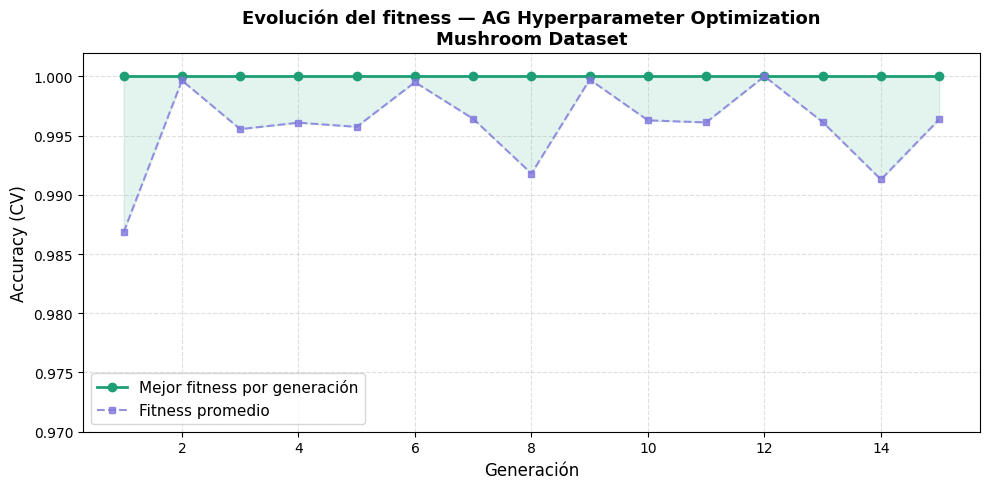

Gráfica guardada como ag_hyperopt_evolucion.png


In [ ]:
# ── Celda 14: GRÁFICA DE EVOLUCIÓN ──────────────────────────

generaciones = list(range(1, len(hist_mejor) + 1))

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(generaciones, hist_mejor, 'o-',  color='#1D9E75', linewidth=2,
        markersize=6, label='Mejor fitness por generación')
ax.plot(generaciones, hist_prom,  's--', color='#7F77DD', linewidth=1.5,
        markersize=5, alpha=0.8, label='Fitness promedio')
ax.fill_between(generaciones, hist_prom, hist_mejor,
                alpha=0.12, color='#1D9E75')

ax.set_xlabel('Generación', fontsize=12)
ax.set_ylabel('Accuracy (CV)', fontsize=12)
ax.set_title('Evolución del fitness — AG Hyperparameter Optimization\nMushroom Dataset',
             fontsize=13, fontweight='bold')
ax.legend(fontsize=11)
ax.set_ylim(0.97, 1.002)
ax.grid(True, linestyle='--', alpha=0.4)
plt.tight_layout()
plt.savefig('ag_hyperopt_evolucion.png', dpi=150, bbox_inches='tight')
plt.show()
print("Gráfica guardada como ag_hyperopt_evolucion.png")